# [Computational Social Science] Project 4: Unsupervised Learning

**Enter your Name:** Gisselle Rodriguez Benitez

*Semester:* Fall 2025

## Data Description and Preprocessing

For this project, you will explore data from the [National Health and Nutrition Examination Survey](https://www.kaggle.com/cdc/national-health-and-nutrition-examination-survey?select=questionnaire.csv). NHANES is a unique study that combines survey methodology with in-person medical examinations to create a dataset with demographic information, health indicators, and health outcomes.

We start by importing the data and doing some preliminary preprocessing for you. We import some libraries that will be helpful as well. 'SEQN' is the ID number for each respondent, and 'HSD010' will be our target outcome. [HSD010](https://wwwn.cdc.gov/Nchs/Nhanes/2013-2014/HSQ_H.htm#HSD010) asks for the respondent's self reported health condition, which can range from "excellent" to "poor."

In [1]:
# Import libraries
import os
os.environ["OMP_NUM_THREADS"] = "9"  # set before importing sklearn

from sklearn.metrics import silhouette_score


import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split
!pip install factor_analyzer
from factor_analyzer import calculate_kmo, FactorAnalyzer

# load libraries
# -----------
import keras
from keras.utils import to_categorical

from tensorflow.keras import Input


In [2]:
# Load nhanes data
nhanes = pd.read_csv('nhanes.csv')
# Get the ID numbers for each observation (seqn)
seqn = nhanes['SEQN']
# Get the target, "self-reported health condition," HSD010
hsd010 = nhanes['HSD010']
# Drop SEQN from the dataframe and then apply the standard scaler
nhanes = nhanes.drop(['SEQN', 'HSD010'], axis = 1)
nhanes_scaled = pd.DataFrame(StandardScaler().fit_transform(nhanes),
                             columns = nhanes.columns)
# Add the ID and target back in
nhanes_scaled['SEQN'] = seqn
nhanes_scaled['HSD010'] = hsd010
nhanes_scaled = nhanes_scaled.set_index('SEQN')
nhanes_scaled.head()

,DR1DRSTZ,DR1EXMER,DRABF,DRDINT,DR1DBIH,DR1DAY,DR1LANG,DR1MNRSP,DR1HELPD,DBQ095Z,...,OHQ770,OHQ845,PAAQUEX,SMQ860,SMQ870,SMQ872,SMQ874,SMQ878,SMAQUEX.x,HSD010
SEQN,,,,,,,,,,,,,,,,,,,,,
73568,0.0,2.034312,0.0,0.324834,-0.393906,1.085853,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-0.646584,-0.484200,1.125008,0.0,-2.081666,1.087115,1.463404,0.612440,1
73576,0.0,0.261930,0.0,-3.078499,0.568251,0.634362,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-1.539259,-0.484200,1.125008,0.0,-2.081666,1.087115,-0.683338,-1.632812,1
73579,0.0,0.728346,0.0,0.324834,1.530407,-1.623092,-0.194202,-0.057306,0.128246,-0.189513,...,0.383802,-1.539259,2.065262,-0.888883,0.0,0.480384,-0.919866,-0.683338,-1.632812,2
73581,0.0,-0.857470,0.0,0.324834,0.480782,1.085853,-0.194202,-0.057306,0.128246,0.080373,...,0.383802,-0.646584,-0.484200,1.125008,0.0,0.480384,-0.919866,-0.683338,0.612440,2
73584,0.0,0.495138,0.0,0.324834,0.305844,-1.623092,-0.194202,-0.057306,0.128246,0.080373,...,-2.605509,0.246091,2.065262,1.125008,0.0,0.480384,-0.919866,1.463404,-1.632812,3


## Plots

Let's take a look at the data. Below we visualize boxplots of family income to federal poverty line ratio ('INDFMPIR') and self-reported health condition. Notice how there are some clear patterns (the lower the ratio, the lower reported health condition), but it's not a perfect separation. We have 240+ features in our dataset, and we likely have several features in our dataset that highly correlate with our family income-poverty line ratio measure - PCA will help us simplify these.

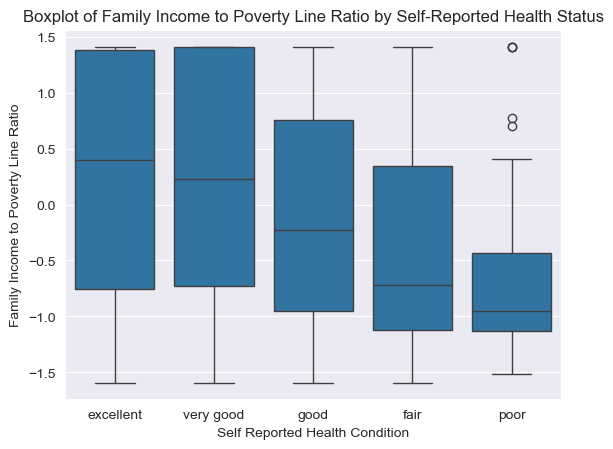

In [3]:
# Create a binary version of hsd010 where 1-3 are "good" and 4-5 are "poor"
nhanes_scaled['HSD010_binary'] = hsd010_binary = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['good', 'good', 'good', 'poor', 'poor']) 
# Recode the original hsd010 with the string labels
nhanes_scaled['HSD010'] = nhanes_scaled['HSD010'].replace(
    [1, 2, 3, 4, 5], ['excellent', 'very good', 'good', 'fair', 'poor'])
# Boxplot of hsd010
ax = sns.boxplot(x = 'HSD010', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Self-Reported Health Status")
plt.show()

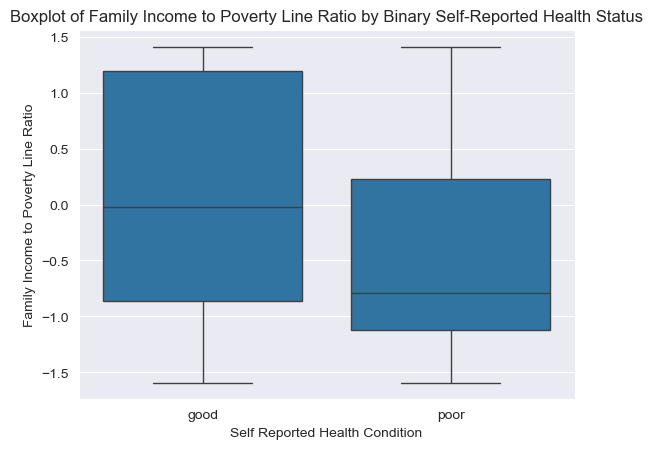

In [4]:
# Boxplot of hsd010_binary
ax = sns.boxplot(x = 'HSD010_binary', y = 'INDFMPIR', data = nhanes_scaled)
ax.set(xlabel = "Self Reported Health Condition",
      ylabel = "Family Income to Poverty Line Ratio")
ax.set_title("Boxplot of Family Income to Poverty Line Ratio by Binary Self-Reported Health Status")
plt.show()

Family income also is not necessarily well correlated with measured health outcomes. See below where we look at the relationship between Body Mass Index (BMI) and the family income-poverty line ratio, and shade points by self-reported health condition. It's hard to find a clear pattern - this is where clustering may come in handy. 

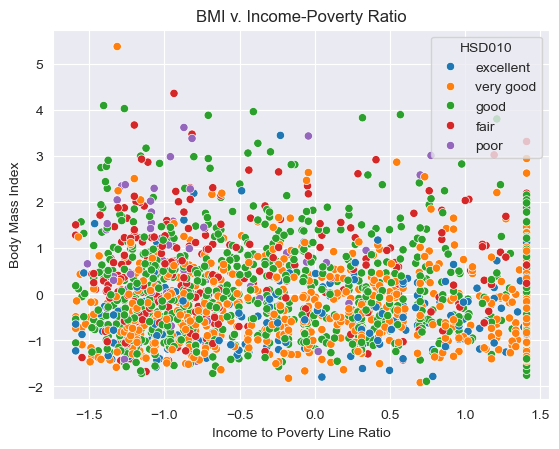

In [5]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = "HSD010", palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

Before we move to working on unsupervised methods, we'll drop our target variables again:

In [6]:
nhanes_scaled = nhanes_scaled.drop(['HSD010', 'HSD010_binary'], axis = 1)

In [7]:
nhanes_scaled.columns

Index(['DR1DRSTZ', 'DR1EXMER', 'DRABF', 'DRDINT', 'DR1DBIH', 'DR1DAY',
       'DR1LANG', 'DR1MNRSP', 'DR1HELPD', 'DBQ095Z',
       ...
       'OHQ033', 'OHQ770', 'OHQ845', 'PAAQUEX', 'SMQ860', 'SMQ870', 'SMQ872',
       'SMQ874', 'SMQ878', 'SMAQUEX.x'],
      dtype='object', length=241)

## Principal Component Analysis

Conduct a Principal Component Analysis (PCA) of the nhanes data. The data has already been prepared for you, so you can work directly on nhanes_scaled. Be sure to do the following:

- Choose the number of components and provide 1-2 sentences about your choice of the number of components. 
- Plot a barplot of the variation explained by each component. *Hint*: look at the attributes associated with your model. 
- Choose how many components you will use to fit a supervised learning model and provide 1-2 sentences to explain that choice.
- Plot a 2D scatterplot of the first two components and provide 1-2 sentences analyzing the plot.

I am checking to see changes in variances-add by additional components, as well as certain variance explained threshold. Then based on this information, I'll the options against interpretability. 

### Train PCA and Discuss Number of Components

In [8]:
print("="*80)
print("PCA Analysis Clustering")
print("="*80)

nhanes_cols = nhanes_scaled.columns

# Fit PCA
pca = PCA().fit(nhanes_scaled)
n = int((pca.explained_variance_ > 1.25 ).sum())

# RESULTS SUMMARY
print("\nRESULTS:")
print(f"{n} components (Eigen> 1.25), explains {pca.explained_variance_ratio_[:n].sum():.1%}")
print("25% variance needs:", int(np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.25) + 1), "components")
print("50% variance needs:", int(np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.5) + 1), "components")
print("75% variance needs:", int(np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.75) + 1), "components")
print("90% variance needs:", int(np.argmax(pca.explained_variance_ratio_.cumsum() >= 0.90) + 1), "components")

print(f"\nDataset: {nhanes_scaled.shape[0]:,} obs × {len(nhanes_cols)} vars")
print(f"Total components available: {pca.n_components_}")



vr = pca.explained_variance_ratio_
cum_vr = vr.cumsum()

# per-component gain in cumulative variance
delta = np.diff(cum_vr)   # same as vr[1:]

# where gain falls below a threshold (e.g., 1%)
threshold = 0.01
idx_thresh = np.argmax(delta < threshold) + 1  # +1: component index
print(f"First component where added variance < {threshold:.0%}: PC{idx_thresh}, "
      f"gain={delta[idx_thresh-1]:.3f}, cum={cum_vr[idx_thresh-1]:.3f}")

# largest relative drop in gain (elbow via second diff)
rel_drop = np.diff(delta)  # change in gains
elbow_idx = np.argmin(rel_drop) + 2  # +2 due to two diffs
print(f"Elbow at ~PC{elbow_idx}: gain={delta[elbow_idx-1]:.3f}, cum={cum_vr[elbow_idx-1]:.3f}")



PCA Analysis Clustering

RESULTS:
42 components (Eigen> 1.25), explains 61.0%
25% variance needs: 4 components
50% variance needs: 25 components
75% variance needs: 73 components
90% variance needs: 120 components

Dataset: 2,064 obs × 241 vars
Total components available: 241
First component where added variance < 1%: PC16, gain=0.009, cum=0.429
Elbow at ~PC2: gain=0.044, cum=0.178


### Barplot of Components

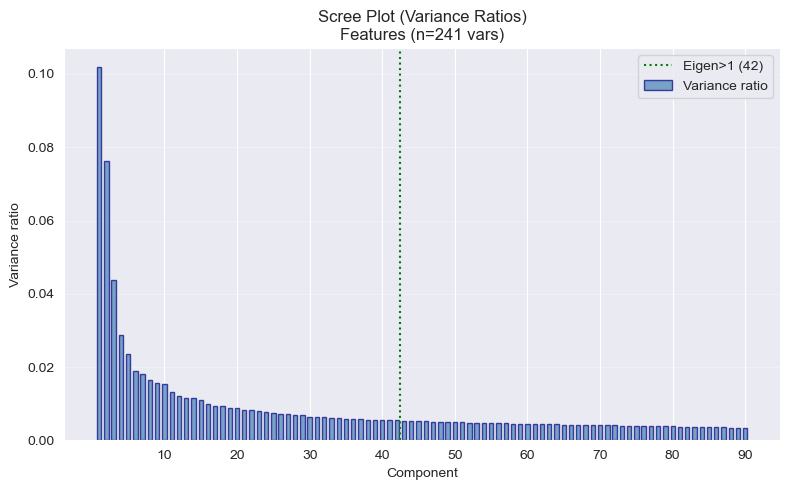

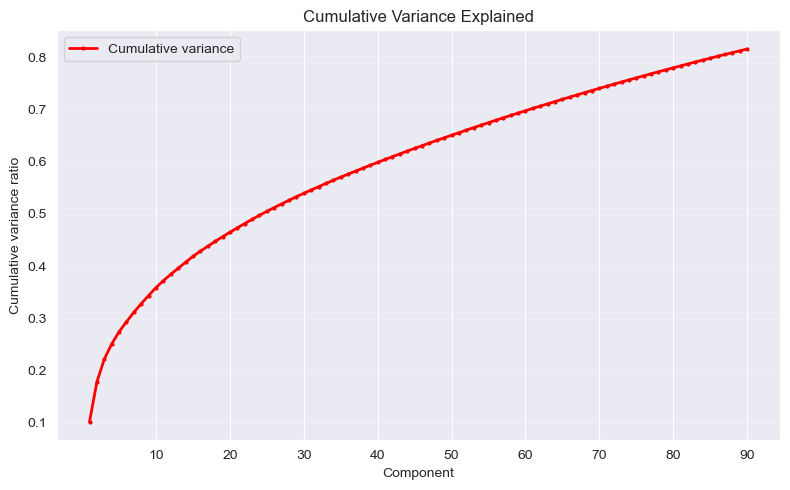

In [9]:
## Bar Screet
plt.figure(figsize=(8, 5))
max_comp = min(90, pca.n_components_)
x = np.arange(1, max_comp + 1)
width = 0.6
vr = pca.explained_variance_ratio_[:max_comp]

plt.bar(x, vr, width, alpha=0.7, color='steelblue', edgecolor='navy', label='Variance ratio')
plt.axvline(x=n + 0.5, color='g', linestyle=':', label=f'Eigen>1 ({n})')

plt.title(f'Scree Plot (Variance Ratios)\nFeatures (n={len(nhanes_cols)} vars)')
plt.xlabel('Component')
plt.ylabel('Variance ratio')
plt.xticks(x[9::10])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Cumulative variance
plt.figure(figsize=(8, 5))
cum_vr = vr.cumsum()

plt.plot(x, cum_vr, 'r.-', linewidth=2, markersize=4, label='Cumulative variance')

plt.title('Cumulative Variance Explained')
plt.xlabel('Component')
plt.ylabel('Cumulative variance ratio')
plt.xticks(x[9::10])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()




### How many components will you use to fit a supervised learning model?

I've decided to use 16 components, based on the change in the added cumulative variance. Components after number 16 add less than 1 percent. Using less than this would likely lead to limit prediction, as the loss of variance would be pretty high. The downside is that 16 may be difficult to interpret.  

In [10]:
# scores for first 16 components from the existing PCA
scores16 = pca.transform(nhanes_scaled)[:, :16]   # shape: (n_samples, 16)

pca_cols = [f'PC{i}' for i in range(1, 17)]
pca_df = pd.DataFrame(scores16, index=nhanes_scaled.index, columns=pca_cols)

# merging
nhanes_scaled_with_pca = nhanes_scaled.copy()
nhanes_scaled_with_pca[pca_cols] = pca_df

print(nhanes_scaled_with_pca.shape)
nhanes_scaled_with_pca.head()

## getting a sense of the loading for description if needed 

#  loadings matrix: variables (rows) × components (cols)
loadings = pd.DataFrame(
    pca.components_.T,              # shape: (n_vars, n_components)
    index=nhanes_scaled.columns,
    columns=[f'PC{i}' for i in range(1, pca.n_components_ + 1)]
)

# restrict to first 16 PCs 
loadings_16 = loadings.iloc[:, :16]

# each PC, get top 3 absolute loadings
wide_rows = []
for pc in loadings_16.columns:
    s = loadings_16[pc]
    top3 = s.reindex(s.abs().sort_values(ascending=False).head(3).index)
    wide_rows.append({
        "PC": pc,
        "Var1": top3.index[0], "Load1": top3.iloc[0],
        "Var2": top3.index[1], "Load2": top3.iloc[1],
        "Var3": top3.index[2], "Load3": top3.iloc[2],
    })

top3_wide = pd.DataFrame(wide_rows)
print(top3_wide)


(2064, 257)
      PC      Var1     Load1      Var2     Load2      Var3     Load3
0    PC1  DR1TPHOS  0.182538  DR1TKCAL  0.181617  DR1TTFAT  0.176109
1    PC2   OHX09TC  0.179868   OHX08TC  0.178332   OHX07TC  0.176963
2    PC3  INDFMPIR  0.246812  INDFMMPI  0.237347  INDHHIN2  0.227369
3    PC4     BMXWT  0.280520   BMXARMC  0.279414  BMXWAIST  0.278649
4    PC5  DR1TS140  0.253063  DR1TS100  0.252634  DR1TS060  0.250477
5    PC6    LBXHGB  0.338456    LBXHCT  0.298854  LBXMCHSI  0.266741
6    PC7  RIAGENDR  0.232492  LBXRBCSI -0.218049   BMXARML -0.195151
7    PC8    DR1TFA  0.232759  LBXMCHSI -0.220419  LBXMCVSI -0.206839
8    PC9   OHX17TC  0.214682   OHX01TC  0.209700   OHX32TC  0.203492
9   PC10   SIALANG  0.269257  RIDRETH1 -0.260341   LBDNENO  0.223164
10  PC11    URDACT  0.388004    URXUMA  0.386622    URXUMS  0.386622
11  PC12  DR1TBCAR  0.196639    URXUMA  0.192280    URXUMS  0.192280
12  PC13  DR1TCHOL  0.301027  DR1TP204  0.293040   DR1TCHL  0.242266
13  PC14    DR1TVK  0.

### 2D Scatterplot of the first two components

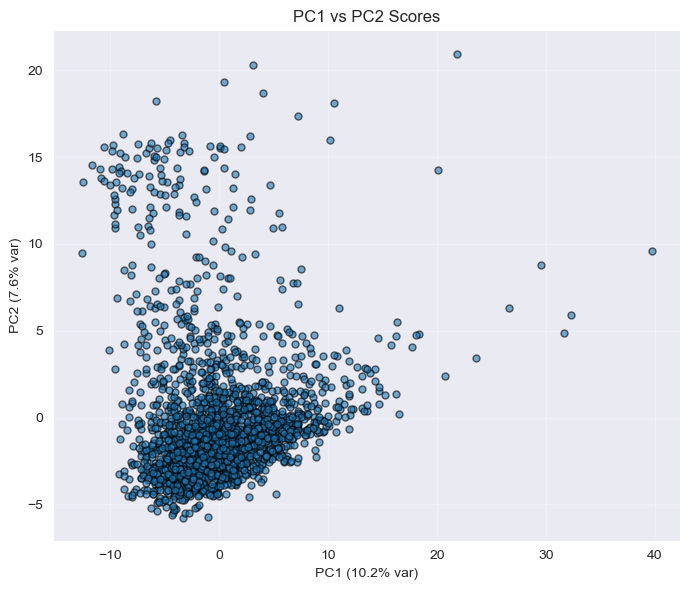

In [11]:
scores = pca.transform(nhanes_scaled)   # shape: (n_samples, n_components)

pc1 = scores[:, 0]
pc2 = scores[:, 1]

plt.figure(figsize=(7, 6))
plt.scatter(pc1, pc2, alpha=0.6, edgecolor='k', s=25)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PC1 vs PC2 Scores')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In the above scatterplot, I see that there is the main, dense cloud between -10, +10 on PC1 and -5 and +2 on PC2. This indicates that these features This indicates there is some dominant dimension, and while theres variation on the tails, there's no clearly separate clusters. The top left, (-10,0) in PC1 and (10,15) on PC2 may be a cluster but its significantlly less dense that the main cloud. I didn't visualize them by the target bariable because I am assuming that we should not be doing this during the unsupervised portion. 

## Clustering

- Choose a clustering algorithm and explain it in 1-2 sentences.
- Cluster the nhanes data. Detail any choice you need to make with regards to number of clusters, and how you arrived at that choice. For instance, you might use the [elbow method](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) if you choose k-means.
- Plot your clusters on top of BMI v. Income Poverty Ratio Plot. Describe what you see in 1-2 sentences.
- Retrain the clustering algorithm, but this time use your PCA results instead of the original dataframe. Plot the clusters on top of the 2D PCA scatterplot from the previous step. Describe your results in 1-2 sentences.

### Choose a Clustering Algorithm

Using K-means and checking siloutte scores below.

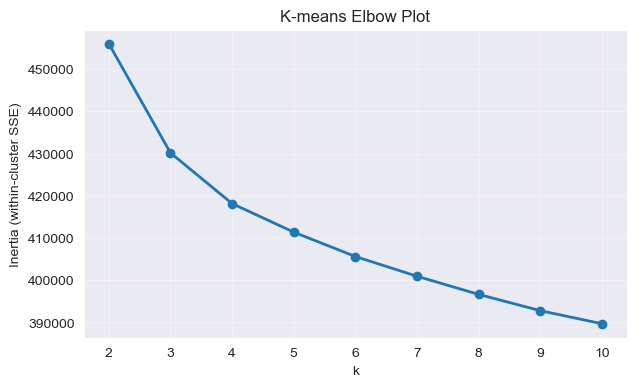

k, inertia: [(2, np.float64(456019.807)), (3, np.float64(430160.983)), (4, np.float64(418153.706)), (5, np.float64(411395.335)), (6, np.float64(405622.284)), (7, np.float64(400949.652)), (8, np.float64(396651.471)), (9, np.float64(392794.288)), (10, np.float64(389710.315))]


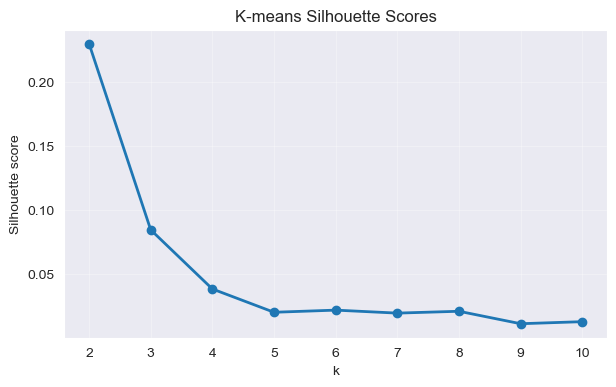

k, silhouette: [(2, np.float64(0.23)), (3, np.float64(0.085)), (4, np.float64(0.038)), (5, np.float64(0.02)), (6, np.float64(0.022)), (7, np.float64(0.02)), (8, np.float64(0.021)), (9, np.float64(0.011)), (10, np.float64(0.013))]


In [12]:
# ignoring for now
import warnings
warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads."
)



X_full = nhanes_scaled.values  

k_range = range(2, 11)
inertia_full = []
sil_full = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    labels = km.fit_predict(X_full)
    inertia_full.append(km.inertia_)                 # within-cluster SSE
    sil_full.append(silhouette_score(X_full, labels))

# Elbow plot on full data
plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia_full, 'o-', linewidth=2)
plt.xlabel('k')
plt.ylabel('Inertia (within-cluster SSE)')
plt.title('K-means Elbow Plot')
plt.grid(True, alpha=0.3)
plt.show()
print("k, inertia:", list(zip(k_range, np.round(inertia_full, 3))))


# silhouette plot on full data
plt.figure(figsize=(7, 4))
plt.plot(k_range, sil_full, 'o-', linewidth=2)
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('K-means Silhouette Scores')
plt.grid(True, alpha=0.3)
plt.show()

print("k, silhouette:", list(zip(k_range, np.round(sil_full, 3))))



I don't believe there is meaningful seperation of clusters at any of these ks. But we have five categories in our target variable. This may be a sign that they are not necessarily clustering into the actual levels (hsd010)

### Cluster nhanes

In [13]:
km_full = KMeans(n_clusters=5, n_init=50, random_state=0)
labels_full = km_full.fit_predict(nhanes_scaled)+1

In [14]:
labels_full

array([3, 5, 5, ..., 5, 3, 2], dtype=int32)

### Plot your clusters on top of the BMI v. Income Poverty Ratio Plot

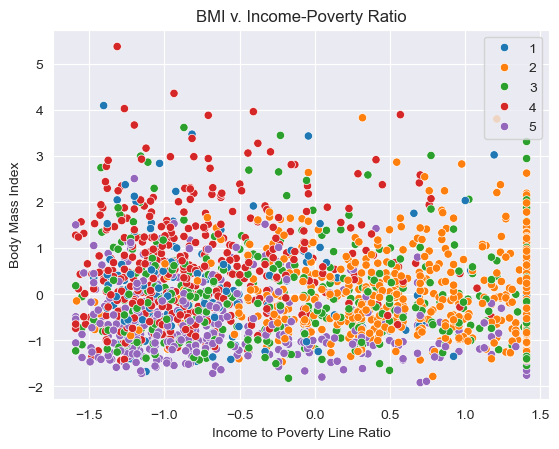

In [15]:
ax = sns.scatterplot(x = "INDFMPIR", y = "BMXBMI", hue = labels_full, palette = "tab10", data = nhanes_scaled)
ax.set(xlabel = "Income to Poverty Line Ratio",
      ylabel = "Body Mass Index")
ax.set_title("BMI v. Income-Poverty Ratio")
plt.show()

In this scatterplot each predicted clusters is spread across the dimensions, but we can see some grouping of clusters: 
- 1. Group 1 is densley clustered in lower BMI, and more weakly clustered within lower income to poverty line ratio
  2. Group 2 is less densley clustered in lower BMI, and more densley clustered within higher income to poverty line ratio
  3. Group 3 is less densley clustered in both dimensions
  4. Group 4 is less densley clustered in both dimensions, though slightly more dense in the lower range of income to poverty line ration
  5. Group 5 is more densley clustered in lower BMI and somewhat clustered at lower income to poverty line ratio

### Retrain the clustering algorithm on PCA components and plot clusters on your 2D scatter

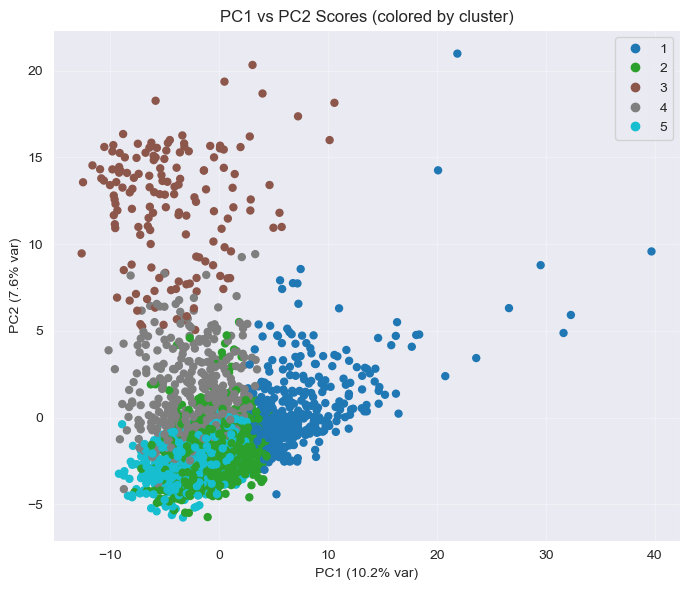

In [16]:
km_pca = KMeans(n_clusters=5, n_init=50, random_state=0)
labels_pca = km_pca.fit_predict(scores16)+1

pc1 = scores[:, 0]
pc2 = scores[:, 1]

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    pc1, pc2,
    c=labels_pca,
    cmap='tab10',
    alpha=1,
    s=25
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title('PC1 vs PC2 Scores (colored by cluster)')
plt.grid(True, alpha=0.3)

#  legend
handles, _ = sc.legend_elements()
plt.legend(handles, [i+1 for i in range(len(handles))])

plt.tight_layout()
plt.show()


Considering these k-means clusters were assigned based on PCs, it makes sense the model has found additional clusters than are visible in the first scatterplot. 

## Neural Network

Now we are ready to predict! Do the following:

- Choose either HSD010 or HSD010\_binary as your target outcome.  
- Train a neural network using the original features. Much of the code to train a basic neural net has been set up for you, but you will need to fill in a couple of missing pieces.
- Train a neural network using only your PCA components as features.
- Train a neural network using your PCA components and the predicted class membership from your clustering algorithm as features.
- Compare and contrast how well each algorithm did. Which featurization technique would you pick and why?

Below we provide a template for training a neural network. Use this template for training on the original features, on the PCA components, and the PCA components + the predicted classes from your clusters.

### Neural Network on Original Features

In [17]:
y = hsd010.replace(
    ['excellent', 'very good', 'good', 'fair', 'poor'],
    [1, 2, 3, 4, 5]
).values     

In [18]:

X = nhanes_scaled

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=10
)

num_classes = 5
y_train_cat = keras.utils.to_categorical(y_train - 1, num_classes=num_classes)
y_test_cat  = keras.utils.to_categorical(y_test - 1,  num_classes=num_classes)
num_classes = y_test_cat.shape[1]

input_dim = X_train.shape[1]
num_pixels = 32

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(num_pixels, kernel_initializer='normal', activation='relu'),
    Dense(num_classes, kernel_initializer='normal', activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=200,
    verbose=2
)


Epoch 1/10
8/8 - 3s - 333ms/step - accuracy: 0.2403 - loss: 1.5859 - val_accuracy: 0.3101 - val_loss: 1.5473
Epoch 2/10
8/8 - 1s - 82ms/step - accuracy: 0.4005 - loss: 1.4972 - val_accuracy: 0.4070 - val_loss: 1.4737
Epoch 3/10
8/8 - 0s - 29ms/step - accuracy: 0.4619 - loss: 1.4200 - val_accuracy: 0.4109 - val_loss: 1.4113
Epoch 4/10
8/8 - 0s - 27ms/step - accuracy: 0.4729 - loss: 1.3561 - val_accuracy: 0.4264 - val_loss: 1.3624
Epoch 5/10
8/8 - 0s - 28ms/step - accuracy: 0.4884 - loss: 1.3072 - val_accuracy: 0.4322 - val_loss: 1.3285
Epoch 6/10
8/8 - 0s - 26ms/step - accuracy: 0.4942 - loss: 1.2701 - val_accuracy: 0.4360 - val_loss: 1.3051
Epoch 7/10
8/8 - 0s - 23ms/step - accuracy: 0.5052 - loss: 1.2393 - val_accuracy: 0.4341 - val_loss: 1.2872
Epoch 8/10
8/8 - 0s - 48ms/step - accuracy: 0.5103 - loss: 1.2128 - val_accuracy: 0.4380 - val_loss: 1.2725
Epoch 9/10
8/8 - 0s - 27ms/step - accuracy: 0.5155 - loss: 1.1870 - val_accuracy: 0.4419 - val_loss: 1.2595
Epoch 10/10
8/8 - 0s - 43ms

### Neural Network on Principal Components

In [19]:
X = scores16

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=10
)

num_classes = 5
y_train_cat = keras.utils.to_categorical(y_train - 1, num_classes=num_classes)
y_test_cat  = keras.utils.to_categorical(y_test - 1,  num_classes=num_classes)
num_classes = y_test_cat.shape[1]

input_dim = X_train.shape[1]
num_pixels = 32

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(num_pixels, kernel_initializer='normal', activation='relu'),
    Dense(num_classes, kernel_initializer='normal', activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=200,
    verbose=2
)


Epoch 1/10
8/8 - 2s - 254ms/step - accuracy: 0.2778 - loss: 1.5921 - val_accuracy: 0.3740 - val_loss: 1.5629
Epoch 2/10
8/8 - 1s - 99ms/step - accuracy: 0.3895 - loss: 1.5491 - val_accuracy: 0.4089 - val_loss: 1.5223
Epoch 3/10
8/8 - 0s - 47ms/step - accuracy: 0.4160 - loss: 1.5083 - val_accuracy: 0.4283 - val_loss: 1.4836
Epoch 4/10
8/8 - 0s - 33ms/step - accuracy: 0.4302 - loss: 1.4696 - val_accuracy: 0.4302 - val_loss: 1.4467
Epoch 5/10
8/8 - 0s - 43ms/step - accuracy: 0.4438 - loss: 1.4319 - val_accuracy: 0.4322 - val_loss: 1.4124
Epoch 6/10
8/8 - 0s - 49ms/step - accuracy: 0.4535 - loss: 1.3971 - val_accuracy: 0.4399 - val_loss: 1.3808
Epoch 7/10
8/8 - 1s - 69ms/step - accuracy: 0.4496 - loss: 1.3641 - val_accuracy: 0.4516 - val_loss: 1.3537
Epoch 8/10
8/8 - 0s - 39ms/step - accuracy: 0.4541 - loss: 1.3358 - val_accuracy: 0.4496 - val_loss: 1.3305
Epoch 9/10
8/8 - 0s - 42ms/step - accuracy: 0.4561 - loss: 1.3112 - val_accuracy: 0.4496 - val_loss: 1.3116
Epoch 10/10
8/8 - 0s - 48ms

### Neural Network on Principal Components + Cluster Membership

In [20]:
labels_col = labels_pca.reshape(-1, 1)

X = np.hstack((scores16, labels_col))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.25, random_state=10
)

num_classes = 5
y_train_cat = keras.utils.to_categorical(y_train - 1, num_classes=num_classes)
y_test_cat  = keras.utils.to_categorical(y_test - 1,  num_classes=num_classes)
num_classes = y_test_cat.shape[1]

input_dim = X_train.shape[1]
num_pixels = 32

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(num_pixels, kernel_initializer='normal', activation='relu'),
    Dense(num_classes, kernel_initializer='normal', activation='softmax')
])

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=200,
    verbose=2
)

Epoch 1/10
8/8 - 2s - 198ms/step - accuracy: 0.2829 - loss: 1.5982 - val_accuracy: 0.3566 - val_loss: 1.5732
Epoch 2/10
8/8 - 0s - 34ms/step - accuracy: 0.3831 - loss: 1.5516 - val_accuracy: 0.4012 - val_loss: 1.5302
Epoch 3/10
8/8 - 0s - 48ms/step - accuracy: 0.4199 - loss: 1.5094 - val_accuracy: 0.4205 - val_loss: 1.4896
Epoch 4/10
8/8 - 0s - 44ms/step - accuracy: 0.4257 - loss: 1.4684 - val_accuracy: 0.4225 - val_loss: 1.4500
Epoch 5/10
8/8 - 0s - 36ms/step - accuracy: 0.4276 - loss: 1.4287 - val_accuracy: 0.4244 - val_loss: 1.4117
Epoch 6/10
8/8 - 0s - 44ms/step - accuracy: 0.4264 - loss: 1.3889 - val_accuracy: 0.4283 - val_loss: 1.3762
Epoch 7/10
8/8 - 0s - 51ms/step - accuracy: 0.4360 - loss: 1.3521 - val_accuracy: 0.4419 - val_loss: 1.3442
Epoch 8/10
8/8 - 0s - 35ms/step - accuracy: 0.4490 - loss: 1.3188 - val_accuracy: 0.4516 - val_loss: 1.3169
Epoch 9/10
8/8 - 0s - 28ms/step - accuracy: 0.4593 - loss: 1.2901 - val_accuracy: 0.4593 - val_loss: 1.2938
Epoch 10/10
8/8 - 0s - 29ms

## Discussion Questions

1. In your own words, what is the difference between PCA and clustering?

> PCA groups columns. Most clearly useful for dimension reduction, PCA reduces these columns by loading the values of base columns into a number of new components, in order of their ability explain variation. It give us flexibility to decide how much variation we want explained by our features. Moreover, it allows us to reduce the number of features inputted into the models, ideally reducing inputted noise so that the models learn more directly meaningful patterns.

> Clustering groups observations.K-means clustering groups observations into certain groups by their similarity along all dimensions. Clustering encodes unsupervised structural differences between groups. One way to use clustering is an additional feature within a training model. If the clusters align with the actual labels, it can make prediction better. But the weaker or more arbitrary the clustering, the label may just add noise. 

2. Did you notice any advantages to combining PCA and clustering? If so, what do you think they were? If not, why do you think you didn't see any gains from this combination?

> Using the same parameters across all neural networks, they each give the same generalizations: ~0.48 accuracy, this suggests the label is hard to predict from these features. Moreover, identifying k-means clusters does not improve vary much due to the weak separation between clusters. 

3. How can unsupervised techniques help with downstream supervised learning tasks when working with "big data?"

> Although there was no major performance gain in this small example, PCA + clustering can become more valuable as we scale. PCA helps with reducing dimensionality and multicollinearity, and potentially with interpretation of results. Clustering helps the model make use of latent structures that may be harder to capture otherwise. 

>With very wide data, PCA reduces dimensionality and multicollinearity, which in turn stabilizes models and lowers the computational cost of prediction by working in a lower‑dimensional space.​ Moreover, PCA can also aid interpretation when paired with rotations like varimax (when appropriate), which redistribute variance to produce components that more clearly align with interpretable variable groupings

> Clustering is most useful when the resulting groups are clearly separated and substantively meaningful, so that the cluster labels can act as an informative additional feature. In those cases, clusters may capture latent groupings. For instance, respondent geography or population density may not be directly measured in the data but nonetheless drive systematic differences in responses.​ Without clustering, these latent structures remain hidden within patterns across many correlated variables. This makes them harder to detect and use directly in supervised models.